In [43]:
# # ECG Analysis - WESAD Dataset
# This notebook analyzes ECG signals from the WESAD dataset and verifies the R-peak detection algorithm


In [44]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import neurokit2 as nk
import warnings

warnings.filterwarnings('ignore')

# Set up paths
BASE_PATH = Path('../../data/processed/wesad')
print(f"Dataset path: {BASE_PATH}")
print(f"Path exists: {BASE_PATH.exists()}")


Dataset path: ..\..\data\processed\wesad
Path exists: True


In [45]:
# Get list of available patients
def get_patient_dirs():
    """Get all patient directories from the WESAD dataset."""
    if not BASE_PATH.exists():
        print(f"Error: Path {BASE_PATH} does not exist")
        return []

    patient_dirs = sorted([d.name for d in BASE_PATH.iterdir() if d.is_dir() and d.name.startswith('S')])
    return patient_dirs

patients = get_patient_dirs()
print(f"Found {len(patients)} patients: {patients}")


Found 15 patients: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [46]:
# Load ECG signal
def load_ecg_signal(patient_id: str, chunk_size: int = 7000):
    """Load ECG signal for a patient."""
    try:
        ecg_path = BASE_PATH / patient_id / 'chest' / 'chest_ECG.csv'

        if not ecg_path.exists():
            print(f"Warning: ECG file not found for {patient_id}")
            return None, None

        ecg_df = pd.read_csv(ecg_path)
        ecg_signal = ecg_df['ECG'].values

        if len(ecg_signal) < chunk_size:
            print(f"Warning: {patient_id} has only {len(ecg_signal)} samples")
            ecg_chunk = ecg_signal
        else:
            ecg_chunk = ecg_signal[:chunk_size]

        sampling_rate = 700  # WESAD ECG sampling rate

        return ecg_chunk, sampling_rate

    except Exception as e:
        print(f"Error loading ECG for {patient_id}: {e}")
        return None, None

# Test loading
if patients:
    test_signal, test_sr = load_ecg_signal(patients[0])
    if test_signal is not None:
        print(f"Successfully loaded {len(test_signal)} samples at {test_sr} Hz")


Successfully loaded 7000 samples at 700 Hz


In [47]:
# Detect R-peaks using NeuroKit2
def detect_rpeaks_neurokit(ecg_signal: np.ndarray, sampling_rate: int = 700):
    """Detect R-peaks using NeuroKit2 library."""
    try:
        signals, info = nk.ecg_process(ecg_signal, sampling_rate=sampling_rate)
        rpeaks = info['ECG_R_Peaks']

        return {
            'rpeaks': rpeaks,
            'processed_signal': signals['ECG_Clean'],
            'rate': signals['ECG_Rate'],
            'info': info
        }
    except Exception as e:
        print(f"Error detecting R-peaks: {e}")
        return None

# Test detection
if patients and test_signal is not None:
    detection_result = detect_rpeaks_neurokit(test_signal, test_sr)
    if detection_result:
        print(f"Detected {len(detection_result['rpeaks'])} R-peaks")


Detected 15 R-peaks


In [48]:
# Plot ECG with R-peaks
def plot_ecg_with_rpeaks(patient_id: str, ecg_signal: np.ndarray, rpeaks: np.ndarray,
                         processed_signal: np.ndarray, sampling_rate: int = 700):
    """Plot ECG signal with detected R-peaks - raw and clean signals in separate subplots."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Set white background
    fig.patch.set_facecolor('white')
    ax1.set_facecolor('white')
    ax2.set_facecolor('white')

    time = np.arange(len(ecg_signal)) / sampling_rate
    time_rpeaks = rpeaks / sampling_rate

    # Plot 1: Raw ECG signal
    ax1.plot(time, ecg_signal, label='Raw ECG', linewidth=0.8, color='blue')
    ax1.set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Amplitude (mV)', fontsize=11, fontweight='bold')
    ax1.set_title(f'Raw ECG Signal - {patient_id}', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='--')

    # Plot 2: Cleaned ECG signal with R-peaks
    ax2.plot(time, processed_signal, label='Cleaned ECG', linewidth=1, color='darkblue')
    ax2.scatter(time_rpeaks, processed_signal[rpeaks], color='red', s=100, marker='X',
               label=f'R-peaks (n={len(rpeaks)})', zorder=5, edgecolors='darkred', linewidth=1.5)
    ax2.set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Amplitude (mV)', fontsize=11, fontweight='bold')
    ax2.set_title(f'Cleaned ECG Signal with R-Peaks - {patient_id} (7000 samples, {sampling_rate} Hz)', fontsize=12, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=10)
    ax2.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()

    return fig


In [49]:
# Process and plot ECG for each patient
chunk_size = 7000
results = {}

print("Processing all patients...")
for patient_id in patients:
    print(f"Processing {patient_id}...", end=' ')

    ecg_signal, sr = load_ecg_signal(patient_id, chunk_size)

    if ecg_signal is None:
        print("FAILED")
        continue

    detection = detect_rpeaks_neurokit(ecg_signal, sr)

    if detection is None:
        print("FAILED")
        continue

    results[patient_id] = {
        'ecg_signal': ecg_signal,
        'sampling_rate': sr,
        'rpeaks': detection['rpeaks'],
        'processed_signal': detection['processed_signal']
    }

    print(f"OK - Detected {len(detection['rpeaks'])} R-peaks")

print(f"\nSuccessfully processed {len(results)} patients")


Processing all patients...
Processing S10... OK - Detected 15 R-peaks
Processing S11... OK - Detected 15 R-peaks
Processing S13... OK - Detected 14 R-peaks
Processing S14... OK - Detected 13 R-peaks
Processing S15... OK - Detected 14 R-peaks
Processing S16... OK - Detected 14 R-peaks
Processing S17... OK - Detected 15 R-peaks
Processing S2... OK - Detected 11 R-peaks
Processing S3... OK - Detected 12 R-peaks
Processing S4... OK - Detected 12 R-peaks
Processing S5... OK - Detected 12 R-peaks
Processing S6... OK - Detected 12 R-peaks
Processing S7... OK - Detected 13 R-peaks
Processing S8... OK - Detected 13 R-peaks
Processing S9... OK - Detected 15 R-peaks

Successfully processed 15 patients


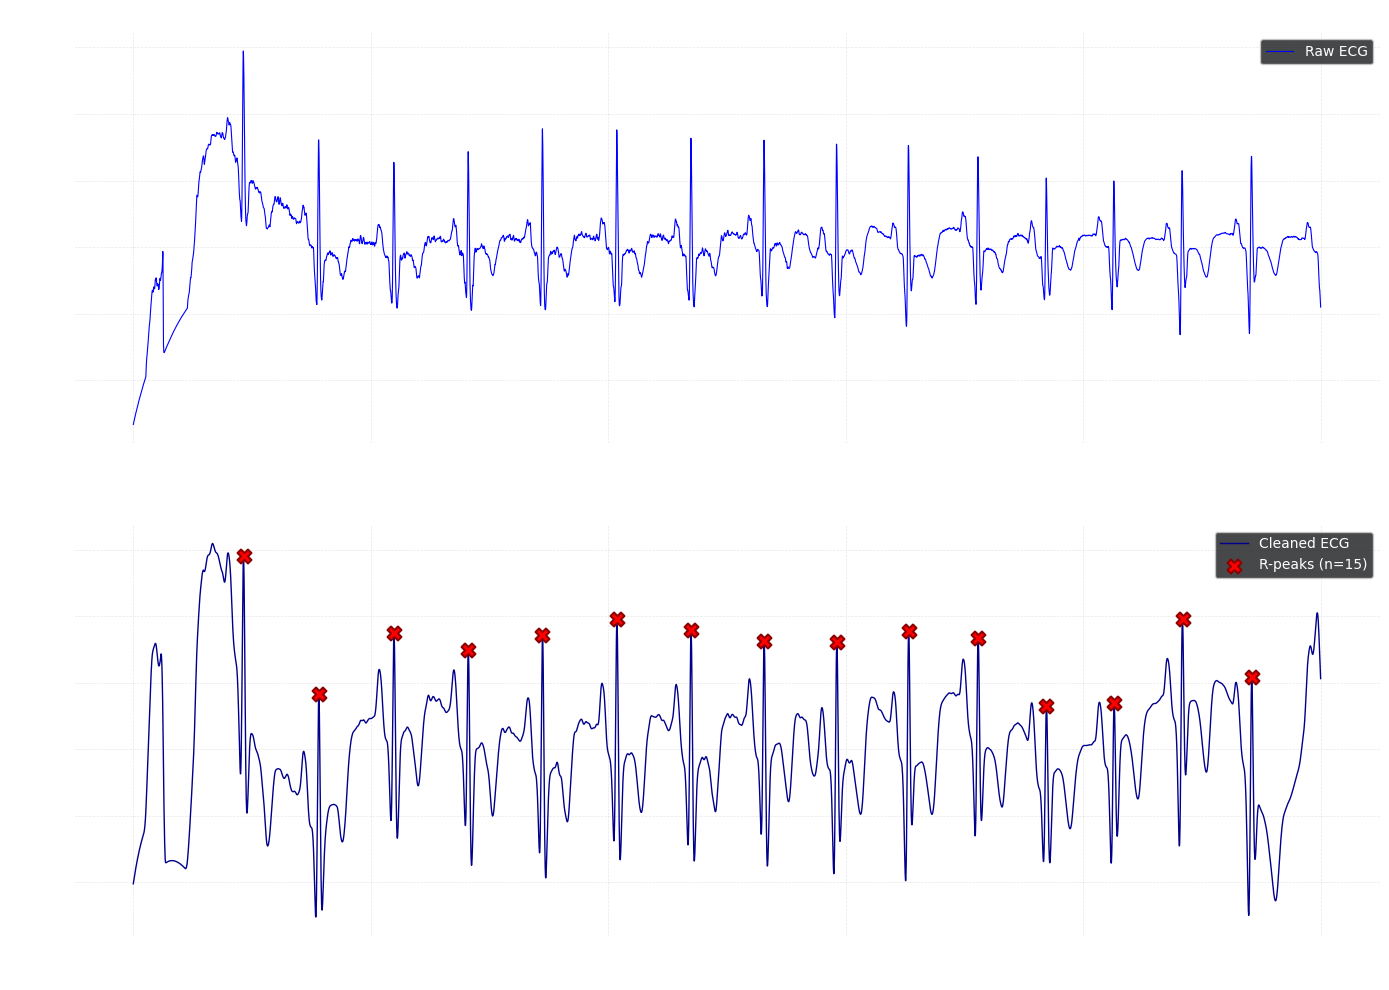


S10 Summary:
  Total R-peaks: 15
  Signal length: 7000 samples (10.00 seconds)


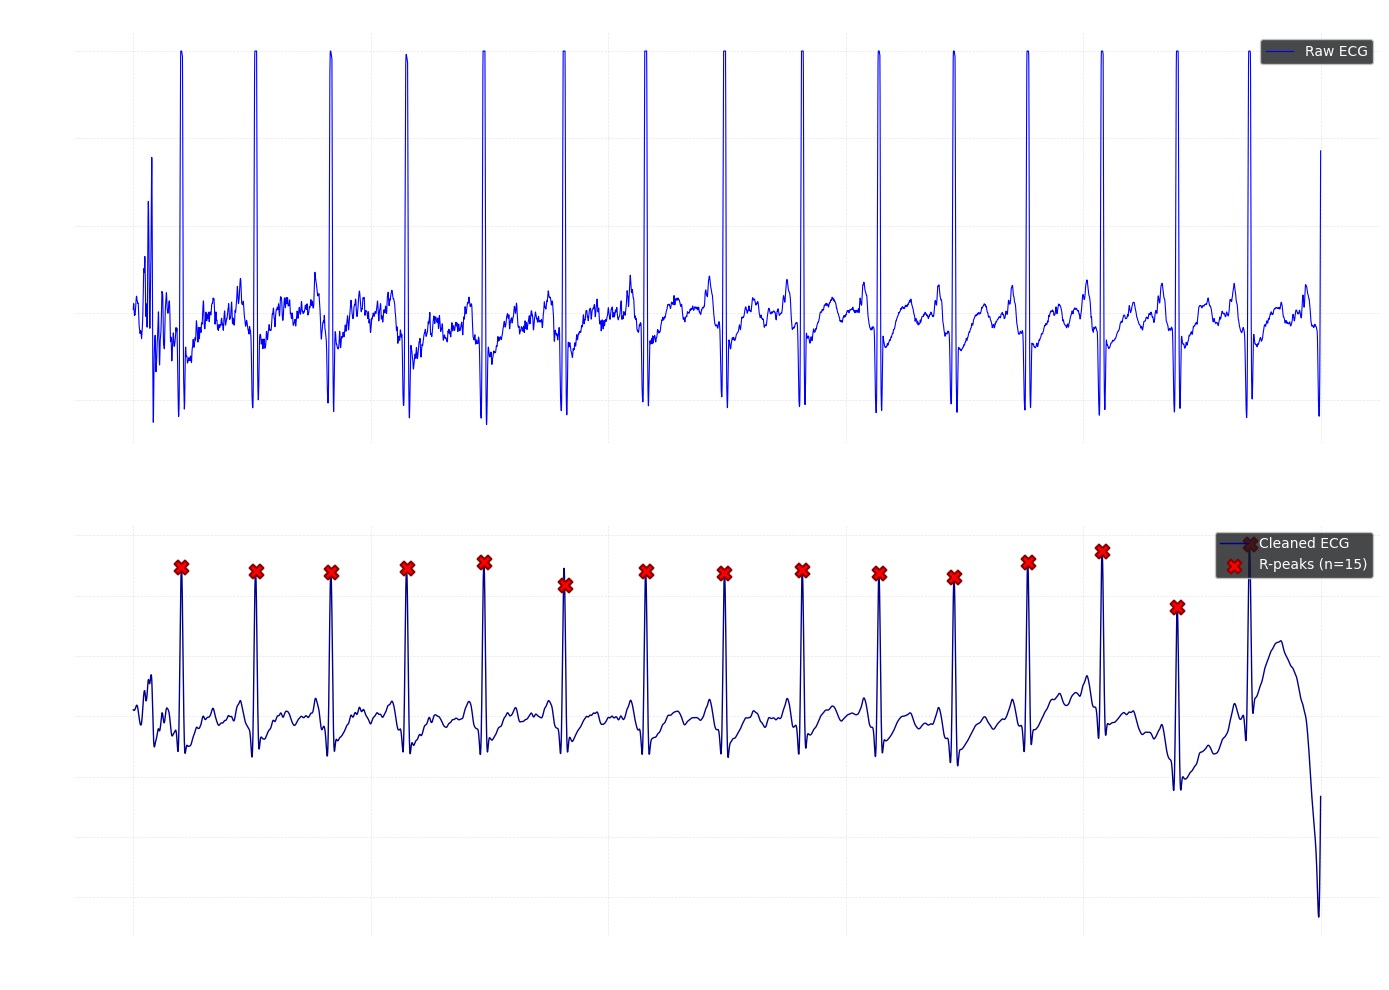


S11 Summary:
  Total R-peaks: 15
  Signal length: 7000 samples (10.00 seconds)


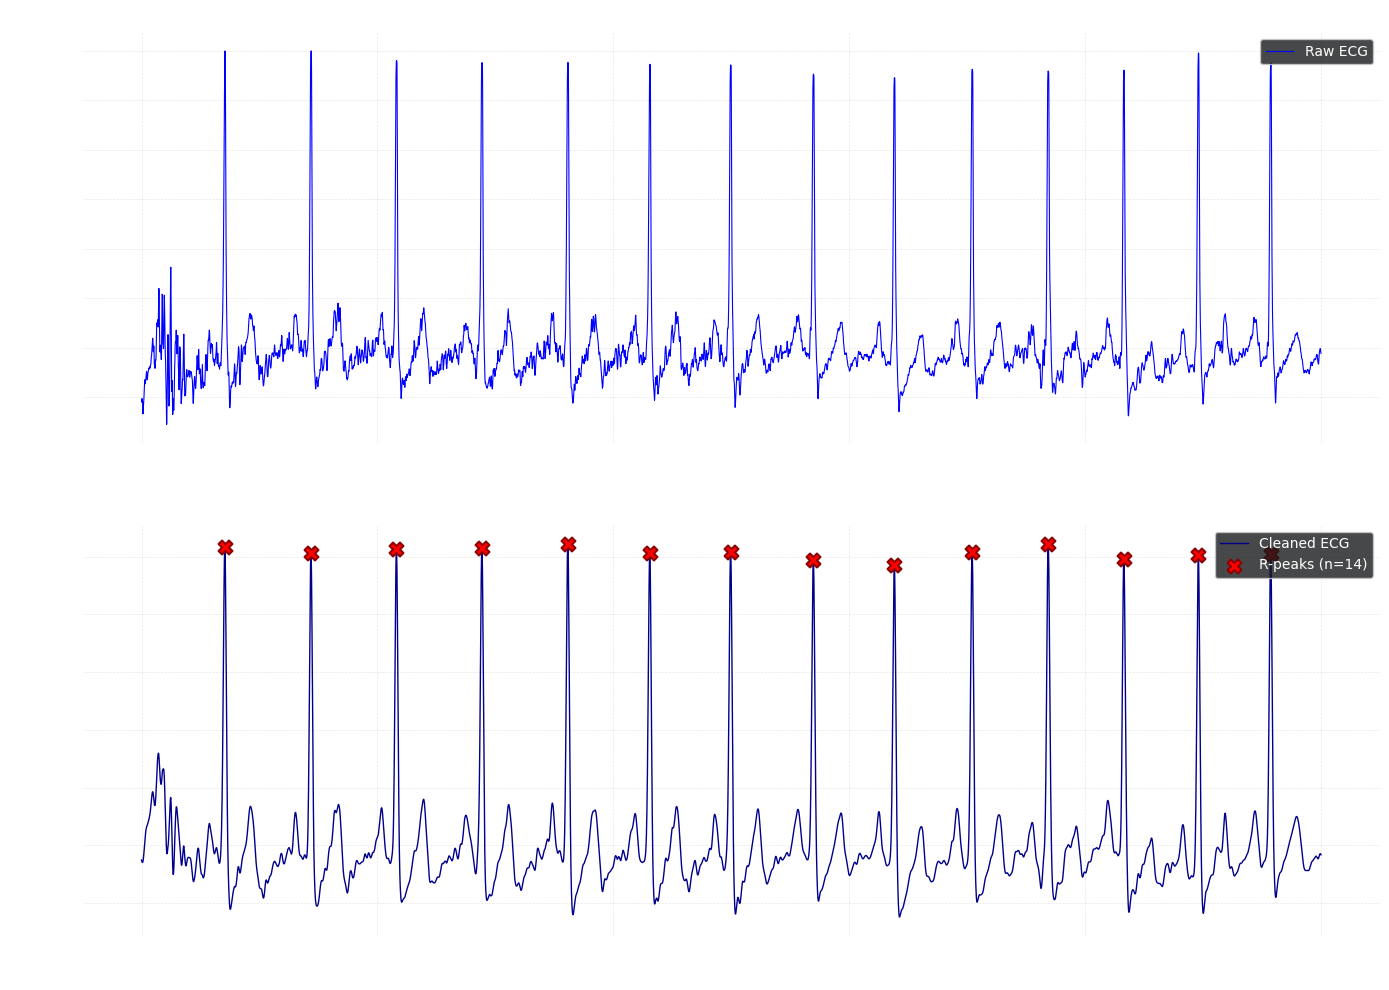


S13 Summary:
  Total R-peaks: 14
  Signal length: 7000 samples (10.00 seconds)


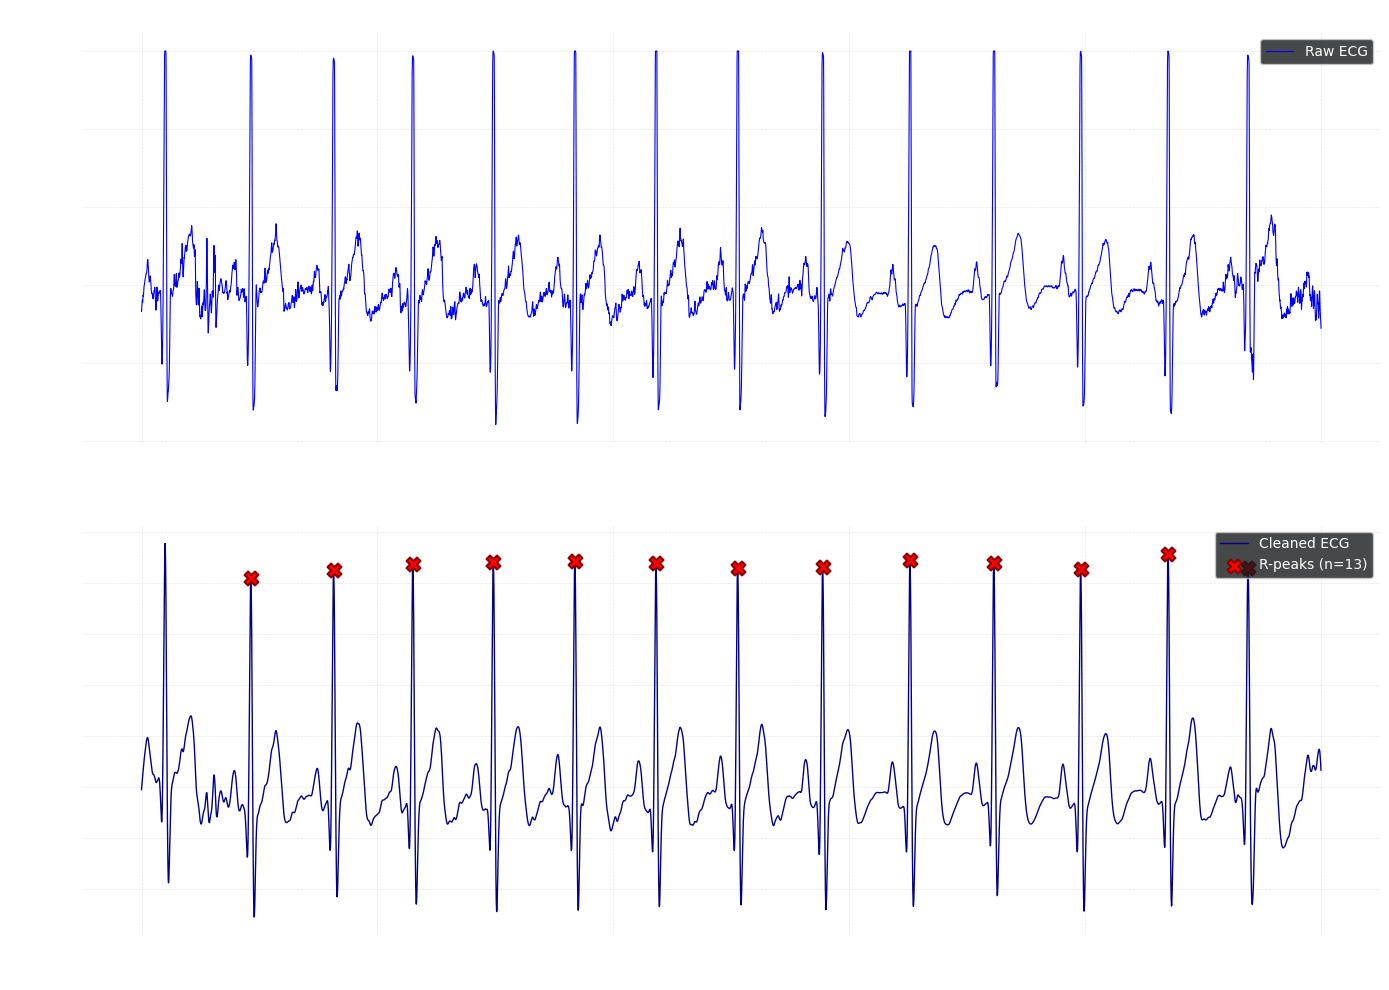


S14 Summary:
  Total R-peaks: 13
  Signal length: 7000 samples (10.00 seconds)


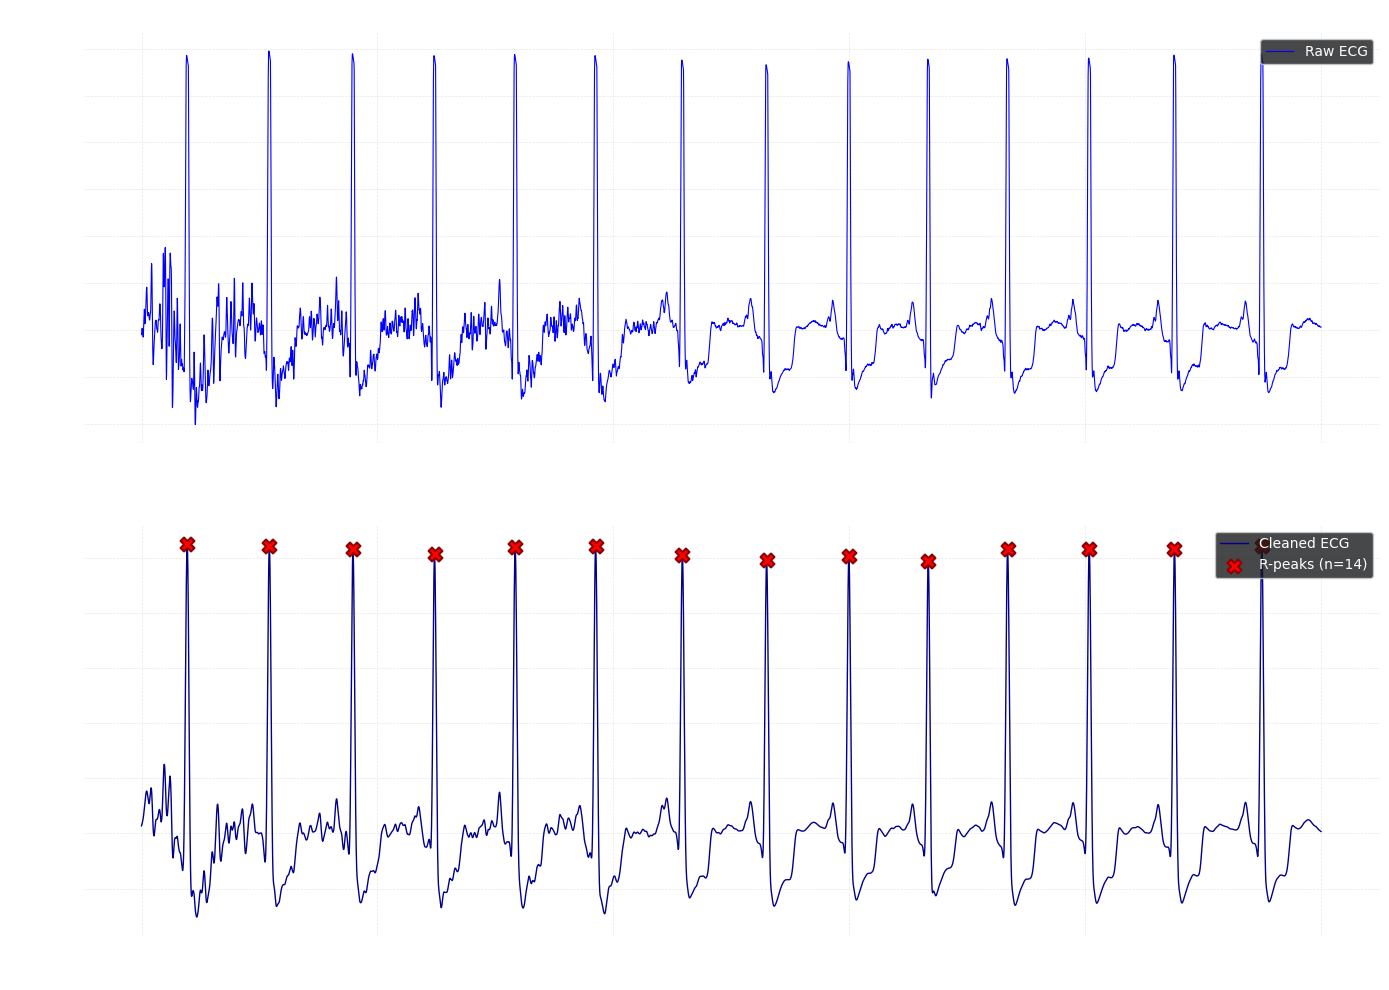


S15 Summary:
  Total R-peaks: 14
  Signal length: 7000 samples (10.00 seconds)


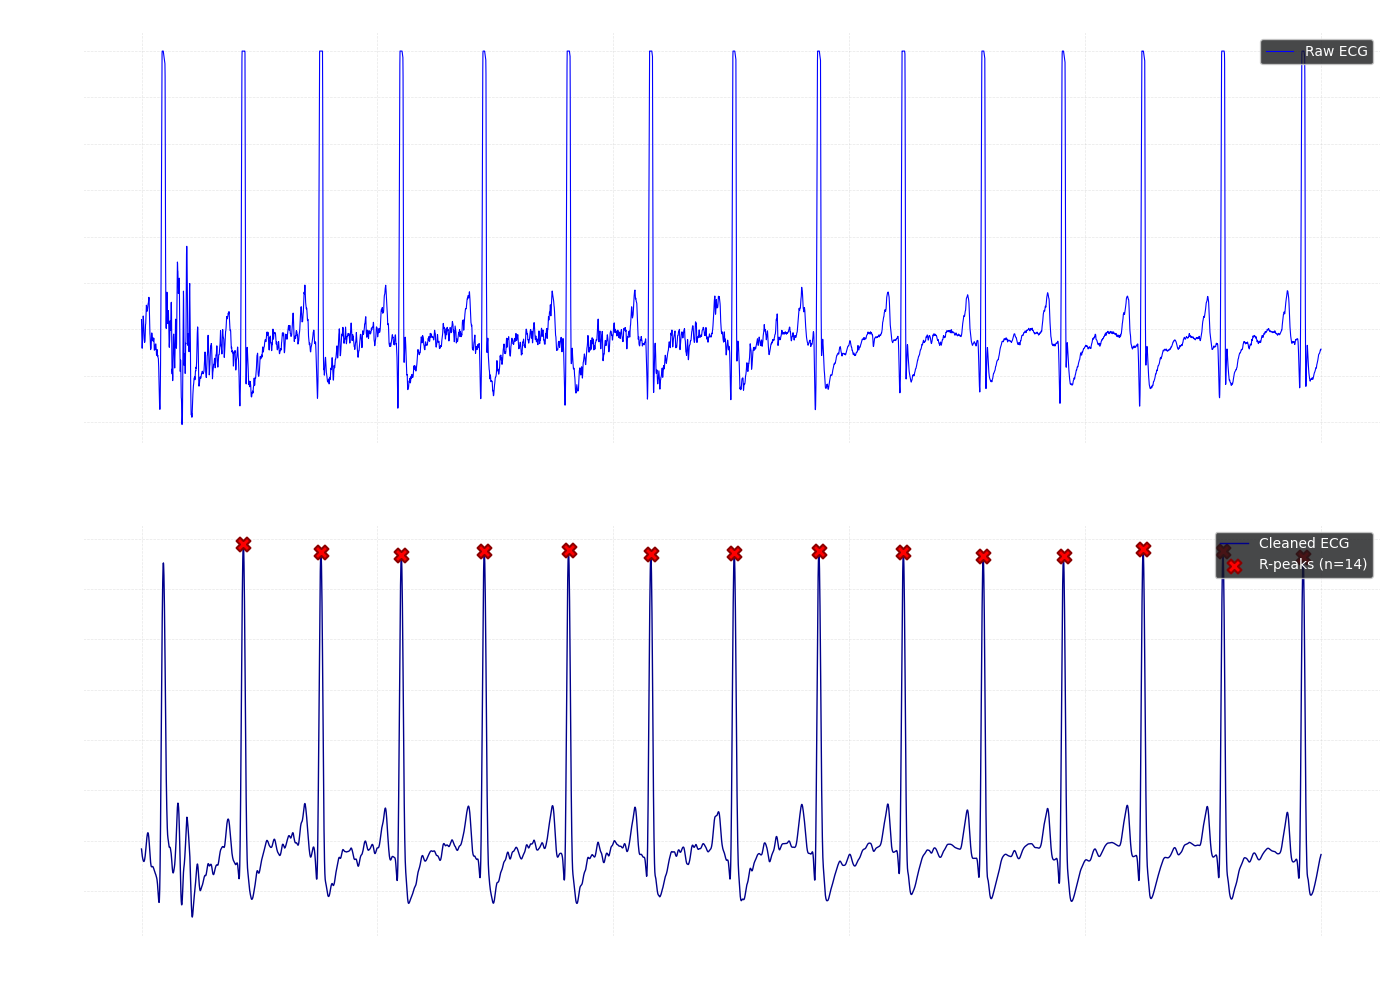


S16 Summary:
  Total R-peaks: 14
  Signal length: 7000 samples (10.00 seconds)


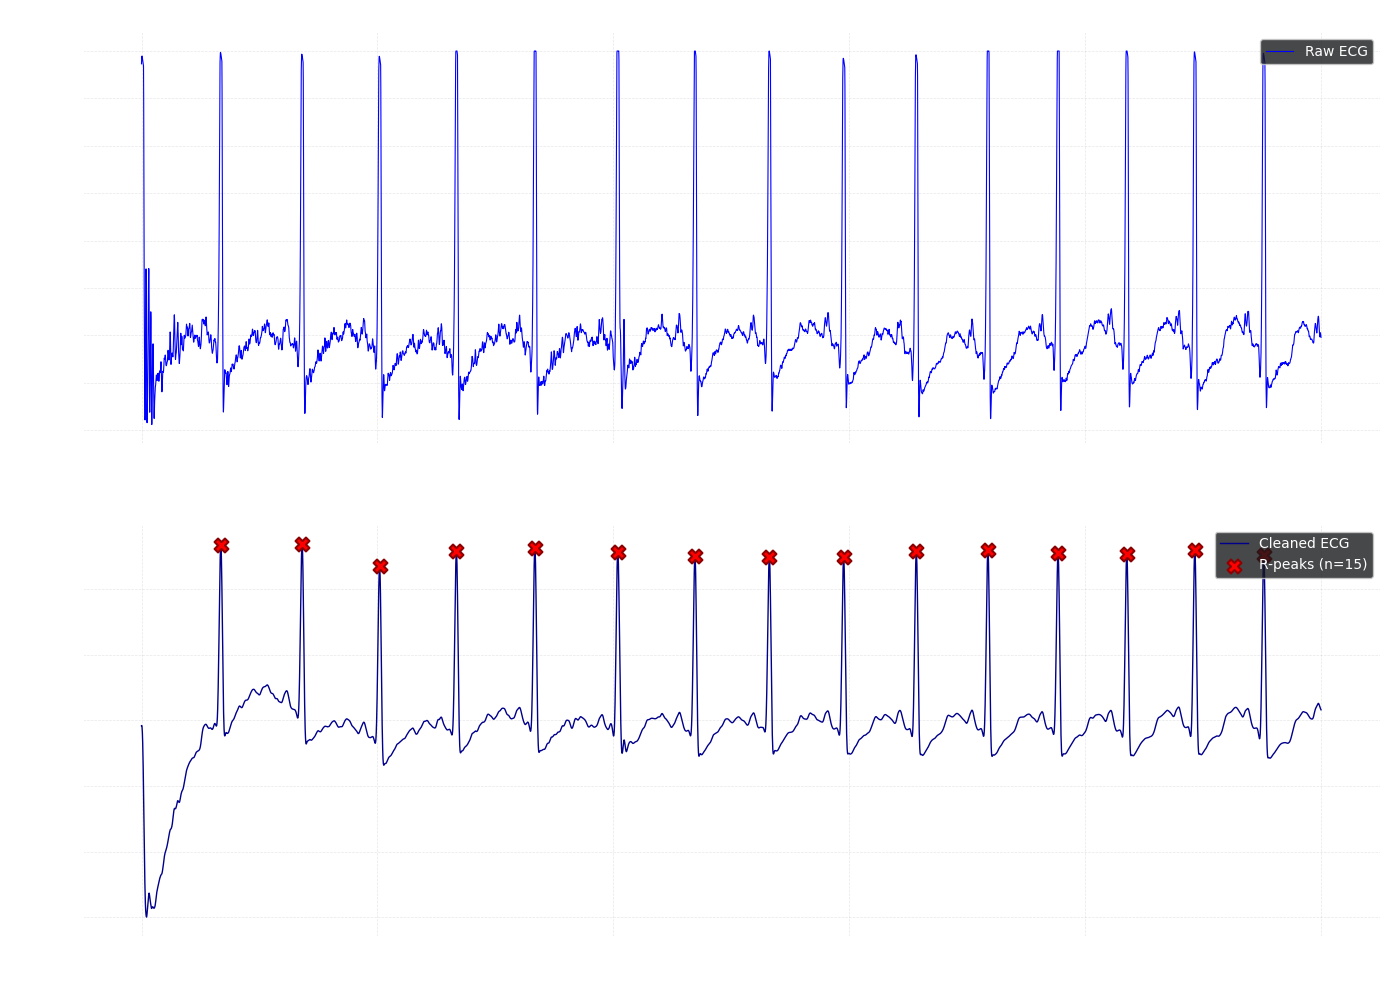


S17 Summary:
  Total R-peaks: 15
  Signal length: 7000 samples (10.00 seconds)


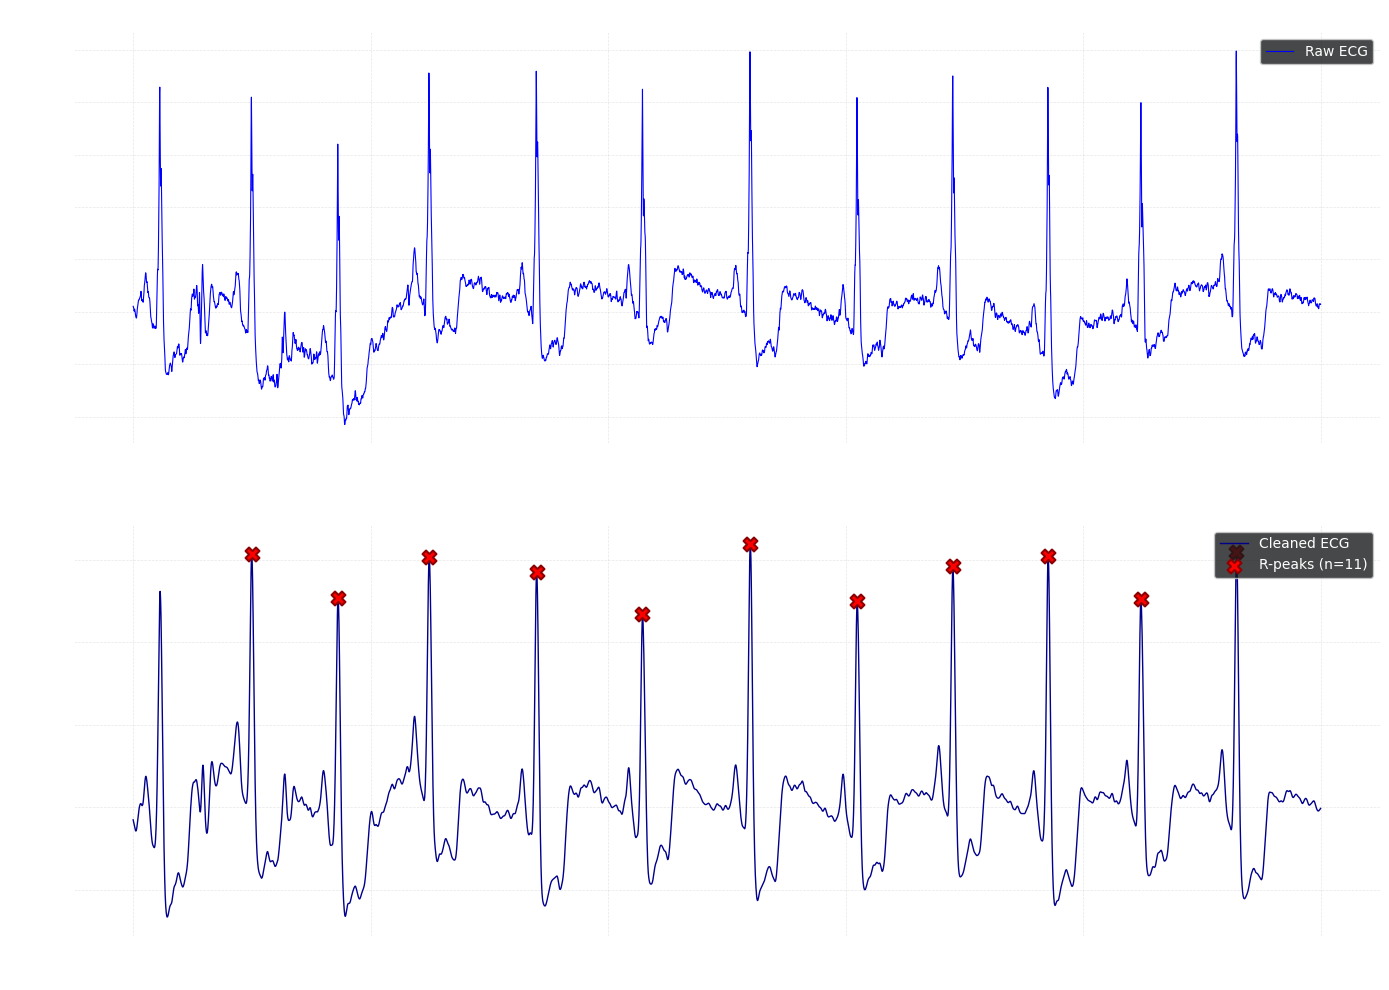


S2 Summary:
  Total R-peaks: 11
  Signal length: 7000 samples (10.00 seconds)


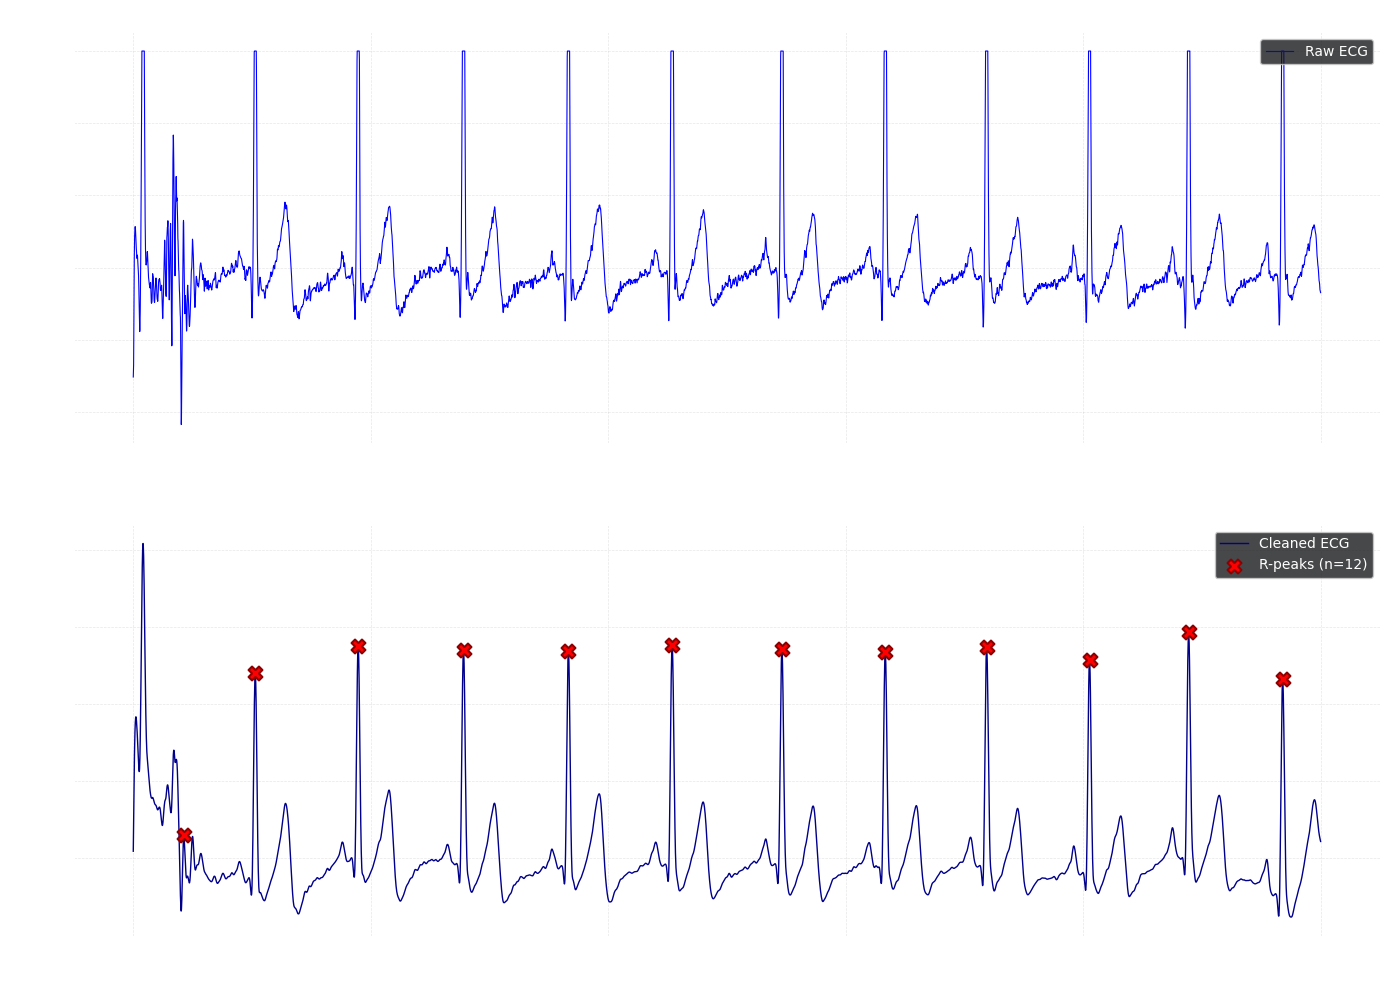


S3 Summary:
  Total R-peaks: 12
  Signal length: 7000 samples (10.00 seconds)


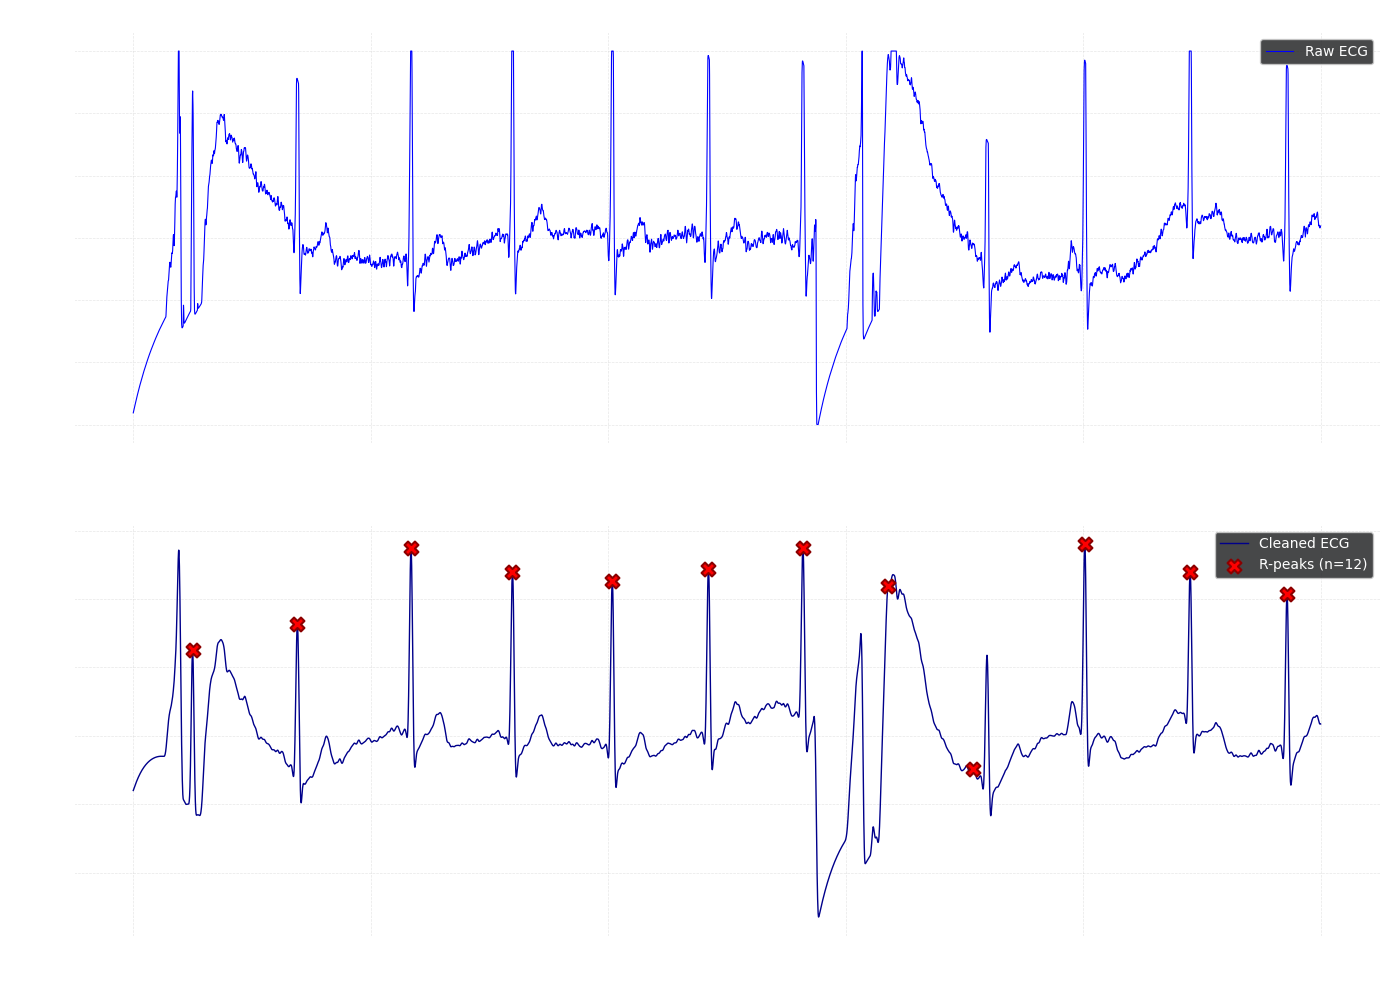


S4 Summary:
  Total R-peaks: 12
  Signal length: 7000 samples (10.00 seconds)


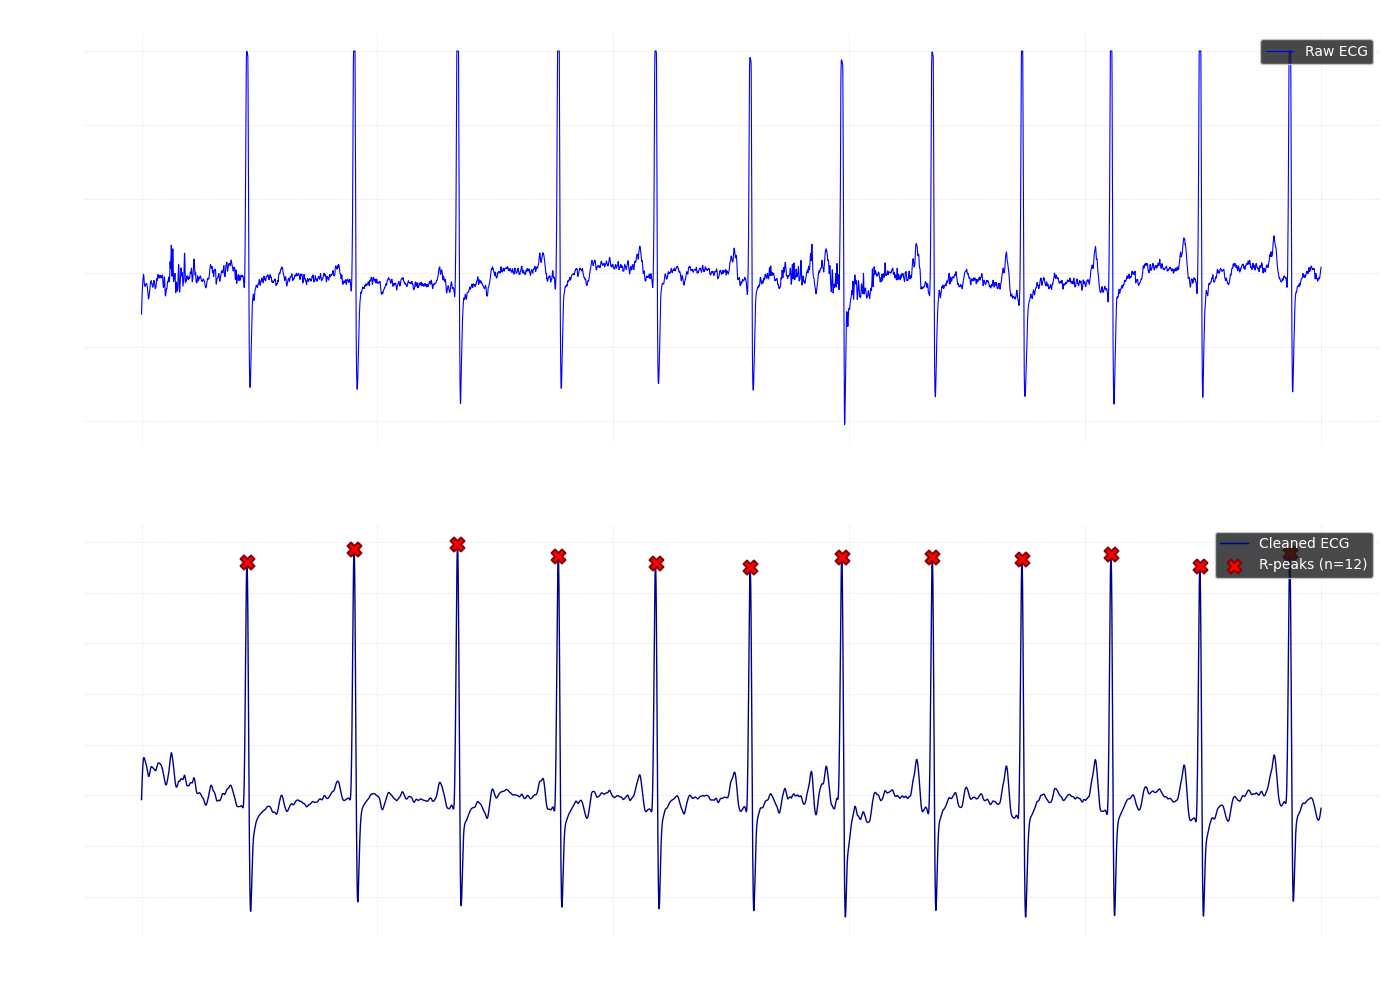


S5 Summary:
  Total R-peaks: 12
  Signal length: 7000 samples (10.00 seconds)


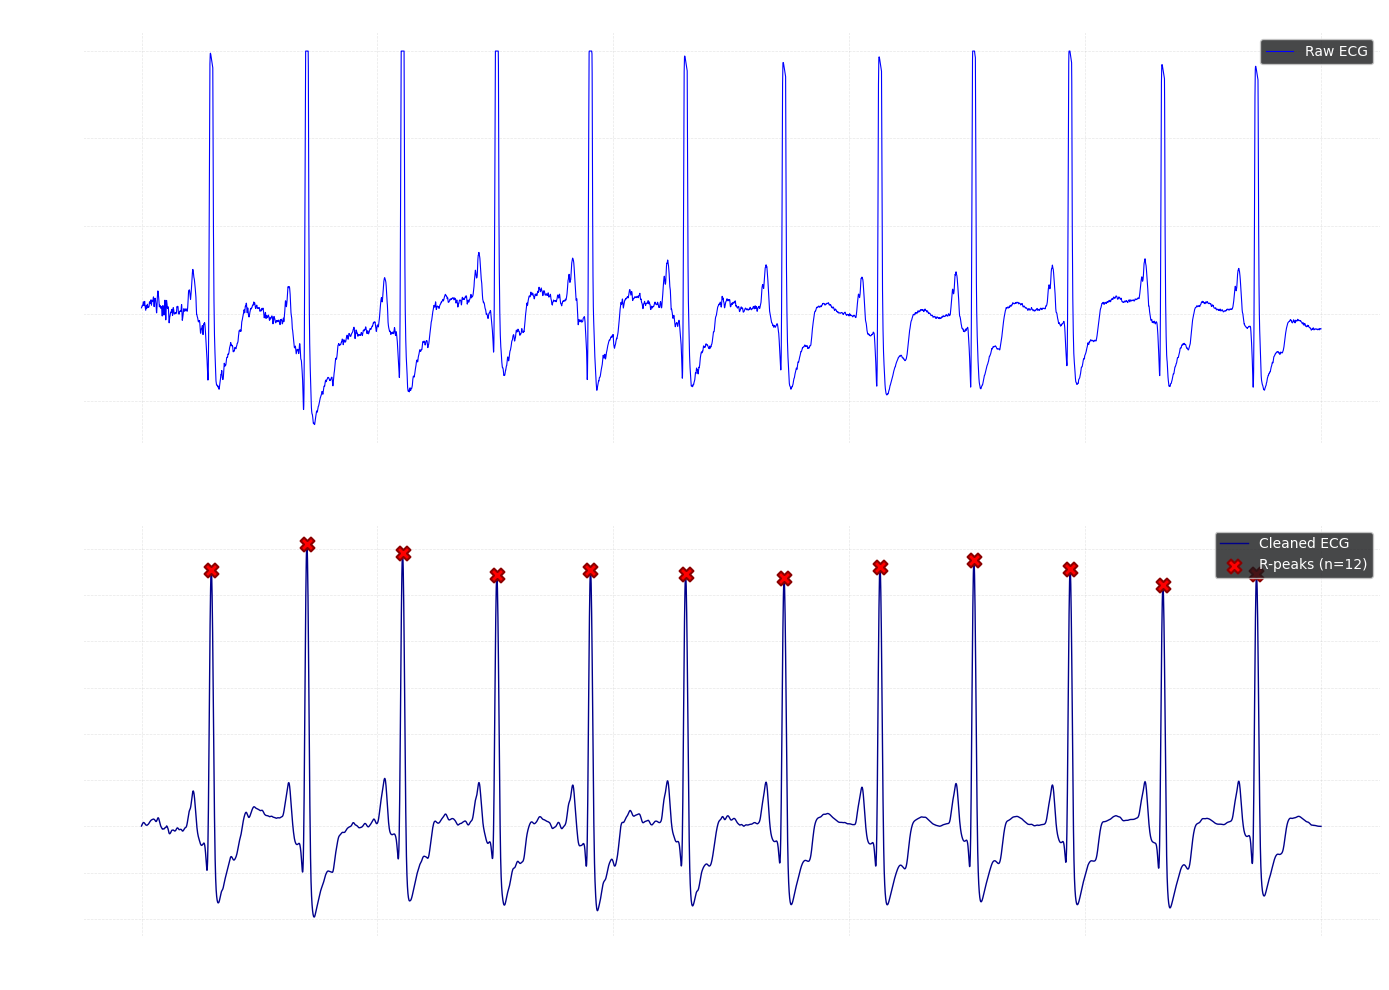


S6 Summary:
  Total R-peaks: 12
  Signal length: 7000 samples (10.00 seconds)


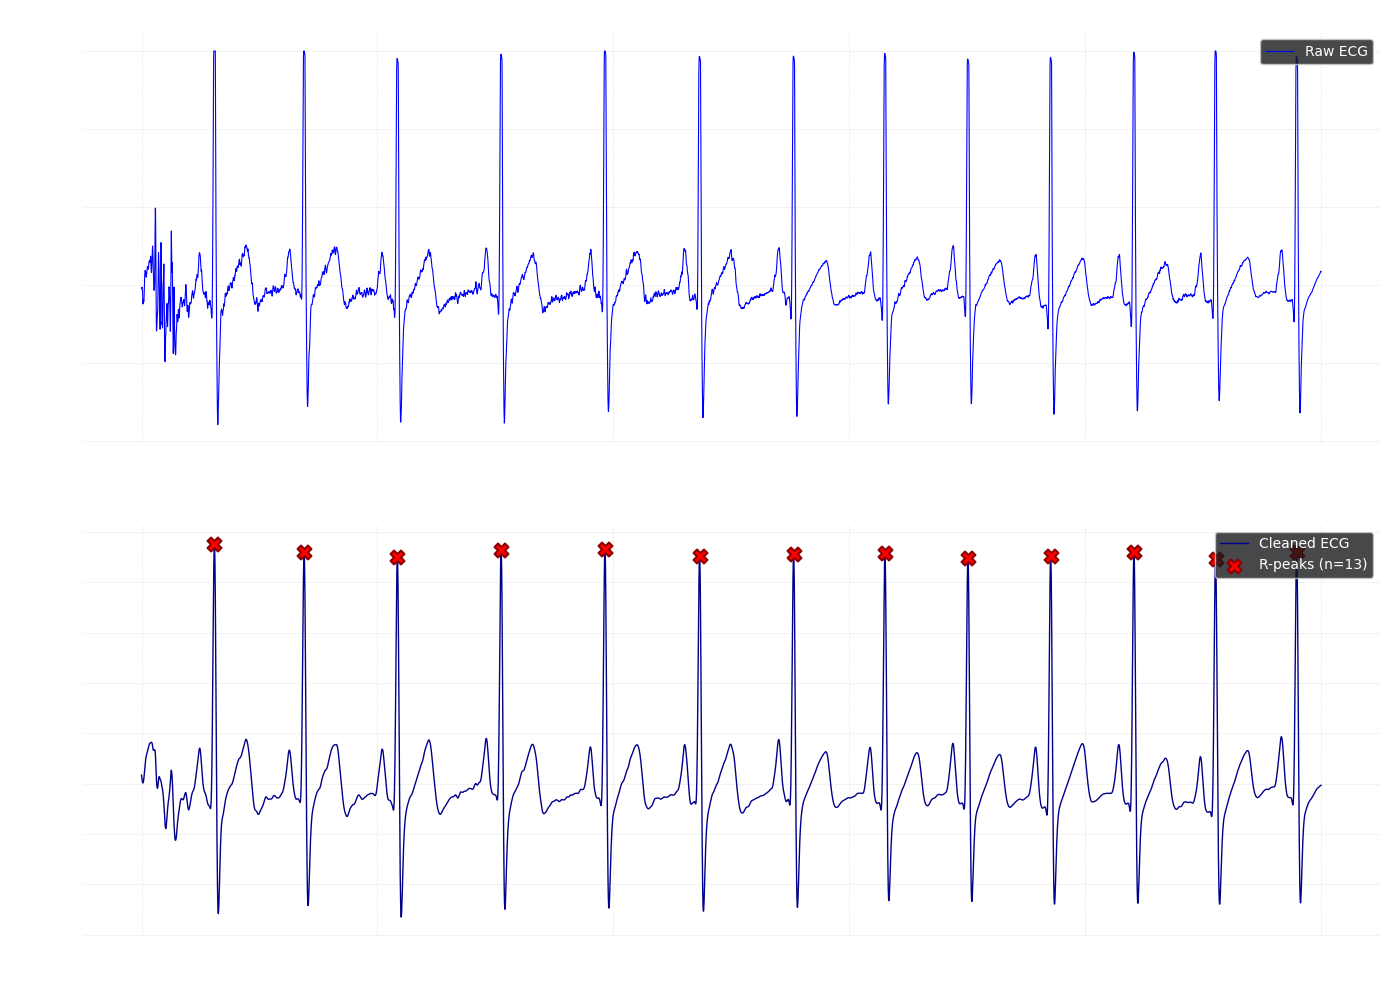


S7 Summary:
  Total R-peaks: 13
  Signal length: 7000 samples (10.00 seconds)


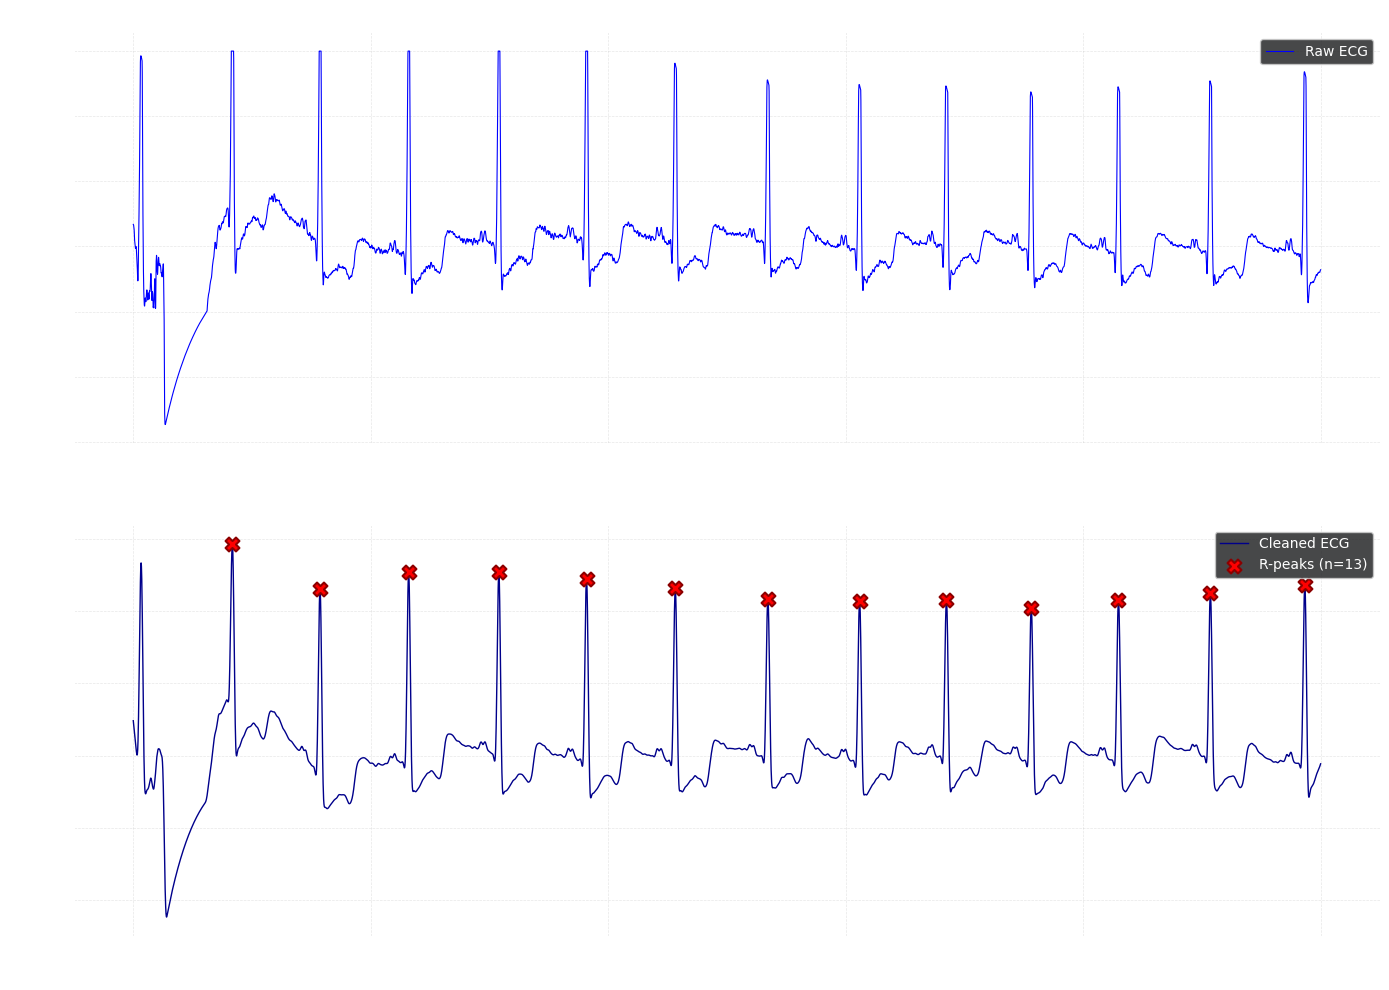


S8 Summary:
  Total R-peaks: 13
  Signal length: 7000 samples (10.00 seconds)


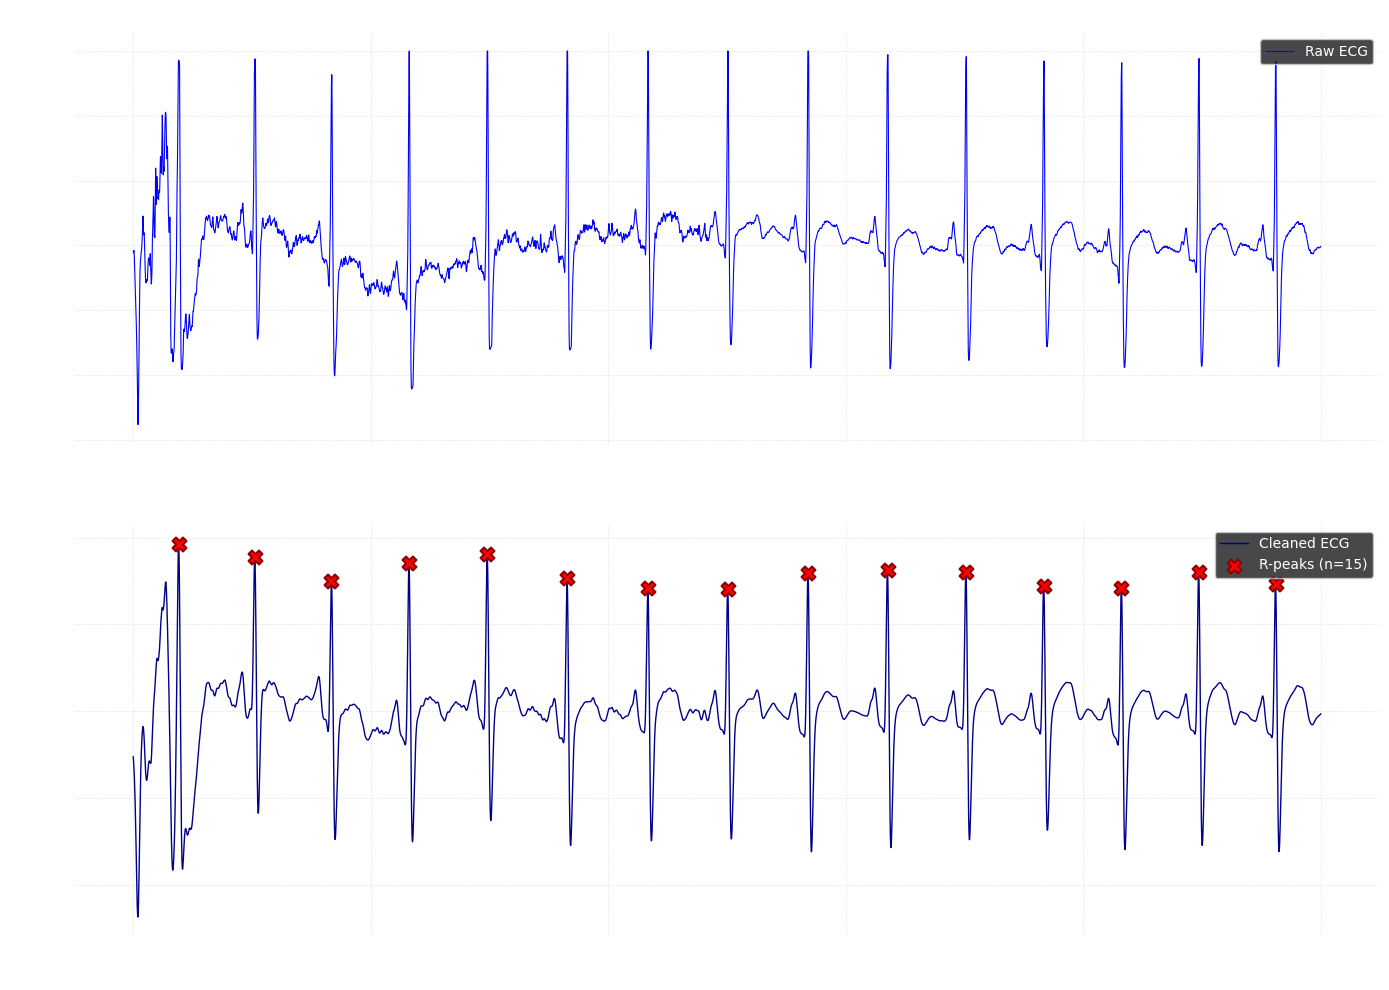


S9 Summary:
  Total R-peaks: 15
  Signal length: 7000 samples (10.00 seconds)


In [50]:
# Plot individual ECG signals
for patient_id, data in results.items():
    fig = plot_ecg_with_rpeaks(
        patient_id,
        data['ecg_signal'],
        data['rpeaks'],
        data['processed_signal'],
        data['sampling_rate']
    )
    plt.show()

    print(f"\n{patient_id} Summary:")
    print(f"  Total R-peaks: {len(data['rpeaks'])}")
    print(f"  Signal length: {len(data['ecg_signal'])} samples ({len(data['ecg_signal'])/data['sampling_rate']:.2f} seconds)")
